<a href="https://colab.research.google.com/github/SaadH-077/geoverdict/blob/main/notebooks/03_timeseries_screening.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 03 — Watching the land: six years of Sentinel-2 per plot, and the statistics arm

**Question this notebook answers:** from each plot's own NDVI/NBR history,
*when* did the forest signal break — and how well does a transparent
robust-statistics detector screen plots, before any deep learning?

**Why start with statistics.** The team-shaped wisdom this project follows:
a change detector you can explain end-to-end — "the plot's NDVI baseline was
0.84 ± 0.02; from July 2022 it sat below 0.45 for four consecutive
observations" — is *evidence*. A neural network's 0.93 is a *score*. A
compliance pipeline wants both, but the statistics arm comes first because
(1) it sets the floor any learned model must beat to justify its complexity,
(2) it produces the breakpoint **date**, which the learned classifier does
not, and the date is what the regulation cares about, and (3) at screening
scale it costs nothing.

**The detector** (`geoverdict.timeseries.detect_break`), and the reasoning
behind each choice:
- **baseline = median, spread = MAD** of the pre-cutoff period — cloud and
  smoke that slip past the mask leave heavy-tailed outliers, and a mean-based
  baseline is dragged by exactly the artefacts we must ignore;
- **break = first run of ≥ 3 consecutive valid observations below
  baseline − max(6·MAD, 0.12)** — one low month is weather, three sustained
  months on a formerly forested plot is clearing. The threshold *adapts per
  plot*: a seasonal plot has a bigger MAD and automatically demands a bigger
  drop;
- **gaps stay gaps** — no interpolation through the wet season; a month with
  no valid observation neither confirms nor breaks a run, and observation
  density is reported so chapter 05 can refuse to certify unobservable plots.

**Produces**
- `outputs/series_monthly.parquet` — per plot, monthly NDVI & NBR (with gaps)
- `outputs/ts_detections.csv` — per plot: breakpoint, magnitude, obs density
- `outputs/rf_arm.joblib`, `outputs/ts_eval.json`
- `figures/g03_*.png`

**Expected runtime:** ~12 minutes (server-side reductions on Earth Engine +
detector fits; no GPU).

### 📦 Where the data in this notebook comes from

| Data | Source | How it enters the notebook |
|---|---|---|
| **Sentinel-2 L2A surface reflectance** (2019–2025) | Copernicus / ESA, hosted on Earth Engine as `COPERNICUS/S2_SR_HARMONIZED` | composited to a masked monthly median server-side, then reduced per plot; ~84 monthly NDVI/NBR values per plot return (cached to `series_raw.parquet`) |
| **SCL cloud mask** | part of each Sentinel-2 L2A scene | used inside the same Earth Engine call to drop cloud/shadow pixels |
| **Hansen post-2020 loss** (reference labels) | Univ. of Maryland, on Earth Engine | the independent referee the detector is scored against |
| **Plot geometries + baselines** | `outputs/plots_analysis.geojson`, `outputs/baseline.csv` from chapters 01–02 | loaded from Drive |

Again nothing large is downloaded — the six-year reflectance history for every
plot is reduced to (plot, date, NDVI, NBR) tuples **on Google's servers**, and
only those tuples come back. The first fetch is cached to Drive, so re-runs
load in seconds.

### Environment setup and persistence

On Colab this clones the repository, installs dependencies, and mounts Google
Drive so that **outputs survive the session**. Locally it is a no-op beyond
putting `src/` on the path.

**Why Drive.** A Colab VM is deleted when the session ends, and the notebooks
depend on each other's artefacts: 01 writes the validated plot portfolio that
every later chapter loads; 02 writes the forest baselines; 03 the time series;
04 the model predictions. `outputs/`, `figures/` and `evidence/` are therefore
redirected to Drive via environment variables that `geoverdict.config` reads
at import time — which is why they must be set *before* the import.

**Re-running this cell picks up code changes**: it hard-resets the clone to
`origin/main` and purges `geoverdict` from `sys.modules` (Python caches
imports; a `git pull` alone leaves the kernel running the old code). Treat the
clone as read-only — edit code locally and push, not inside `/content`.

In [29]:
# --- edit these if you are running your own fork ---------------------------
GITHUB_USER = "SaadH-077"
USE_DRIVE = True          # False -> everything stays in the ephemeral session
# ---------------------------------------------------------------------------

import os, subprocess, sys
from pathlib import Path

IN_COLAB = "google.colab" in sys.modules
REPO = "geoverdict"

if IN_COLAB:
    if USE_DRIVE:
        from google.colab import drive
        drive.mount("/content/drive")
        PERSIST = Path("/content/drive/MyDrive/geoverdict")
        for sub in ("outputs", "figures", "outputs/evidence"):
            (PERSIST / sub).mkdir(parents=True, exist_ok=True)
        os.environ["GEOVERDICT_OUTPUT_DIR"] = str(PERSIST / "outputs")
        os.environ["GEOVERDICT_FIGURE_DIR"] = str(PERSIST / "figures")
        os.environ["GEOVERDICT_EVIDENCE_DIR"] = str(PERSIST / "outputs" / "evidence")
        print("persisting outputs and figures to", PERSIST)

    if not Path(REPO).exists():
        subprocess.run(["git", "clone", "--depth", "1",
                        f"https://github.com/{GITHUB_USER}/{REPO}.git"], check=False)
    if Path(REPO).exists():
        os.chdir(REPO)
        subprocess.run(["git", "fetch", "--quiet", "--depth", "50", "origin", "main"], check=False)
        before = subprocess.run(["git", "rev-parse", "HEAD"], capture_output=True, text=True).stdout.strip()
        subprocess.run(["git", "reset", "--hard", "--quiet", "origin/main"], check=False)
        after = subprocess.run(["git", "rev-parse", "HEAD"], capture_output=True, text=True).stdout.strip()
        if before != after:
            print(f"repo updated {before[:7]} -> {after[:7]}")
    try:
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-r", "requirements.txt"], check=True)
    except subprocess.CalledProcessError as exc:
        print("!! dependency install failed:", exc)
        print("!! continuing anyway - the cells below will report what is missing")

ROOT = Path.cwd() if Path.cwd().name == REPO or (Path.cwd() / "src").exists() else Path.cwd().parent
if str(ROOT / "src") not in sys.path:
    sys.path.insert(0, str(ROOT / "src"))

# Purge cached geoverdict modules so a repo update takes effect in THIS kernel.
for m in [m for m in list(sys.modules) if m == "geoverdict" or m.startswith("geoverdict.")]:
    del sys.modules[m]

from geoverdict import config as cfg
from geoverdict import viz

cfg.ensure_dirs()
viz.set_style()
print(f"outputs -> {cfg.OUTPUT_DIR}")
print(f"figures -> {cfg.FIGURE_DIR}")
print(f"seed = {cfg.SEED}, AOI = {cfg.AOI_NAME} {cfg.AOI_BBOX}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
persisting outputs and figures to /content/drive/MyDrive/geoverdict
outputs -> /content/drive/MyDrive/geoverdict/outputs
figures -> /content/drive/MyDrive/geoverdict/figures
seed = 77, AOI = novo_progresso_para_brazil (-55.6, -7.4, -55.2, -7.0)


In [30]:
EE_PROJECT = "remove-duplicates-487617"   # <- same Earth Engine project id as chapter 02

from geoverdict import gee
gee.init(project=EE_PROJECT or None)

import geopandas as gpd
import numpy as np
import pandas as pd

plots = gpd.read_file(cfg.OUTPUT_DIR / "plots_analysis.geojson")
baseline = pd.read_csv(cfg.OUTPUT_DIR / "baseline.csv", dtype={"plot_id": str})
plots = plots.merge(baseline, on="plot_id", suffixes=("", "_b"))
print(f"{len(plots)} plots with baselines")

501 plots with baselines


### The screening subset, chosen honestly

Six years × ~70 usable scenes/year × every plot is cheap server-side, but the
transfer and the per-plot detector fits are not free, and this chapter should
run in minutes, not hours. We screen a **stratified subset of 200 plots**:
stratified by Hansen post-2020 loss (so both changed and stable plots are
well represented — a uniform draw from a portfolio that is mostly stable
forest would leave the "clearing" stratum too thin to measure recall on),
seeded for reproducibility.

Scaling note, because it matters in review: nothing in the method changes at
10⁵ plots — the reduction is already server-side; you shard the plot list and
parallelise the transfer. The subset is a *notebook-runtime* decision, not an
architectural one.

In [31]:
rng = np.random.default_rng(cfg.SEED)
loss = plots["hansen_loss_post_frac"].fillna(0)

changed = plots.index[loss > cfg.POS_LOSS_FRAC].to_numpy()
stable  = plots.index[loss < cfg.NEG_LOSS_FRAC].to_numpy()
middle  = plots.index[(loss >= cfg.NEG_LOSS_FRAC) & (loss <= cfg.POS_LOSS_FRAC)].to_numpy()

n_changed = min(len(changed), cfg.TS_SUBSET // 3)
n_middle  = min(len(middle),  cfg.TS_SUBSET // 6)
n_stable  = cfg.TS_SUBSET - n_changed - n_middle
subset_idx = np.concatenate([
    rng.choice(changed, n_changed, replace=False),
    rng.choice(middle,  n_middle,  replace=False),
    rng.choice(stable,  min(n_stable, len(stable)), replace=False),
])
sub = plots.loc[subset_idx].reset_index(drop=True)
print(f"screening subset: {len(sub)} plots "
      f"({n_changed} changed / {n_middle} ambiguous / {len(sub)-n_changed-n_middle} stable by Hansen)")

screening subset: 200 plots (66 changed / 33 ambiguous / 101 stable by Hansen)


### Fetching the series (cached — re-runs are instant)

One server-side pass over 2019→2025. Each calendar month is composited to a
**masked median** on Earth Engine's servers *before* anything is transferred,
then reduced over each plot — so we pull ~84 monthly values per plot instead of
thousands of raw scenes. This is deliberate on two counts: it is exactly the
monthly series the detector consumes, and reducing every raw scene over every
plot would blow past Earth Engine's 5000-element interactive query limit on a
multi-tile AOI. The median is also robust to residual cloud the SCL mask
missed, and the SCL classes are shared with the STAC chip path in chapter 04
(`gee.cfg_bad_scl()`), so both paths apply one usability definition. A
plot-month with < 30% valid pixels comes back as *no observation* — a real gap,
never an invented value.

In [32]:
cache = cfg.OUTPUT_DIR / "series_raw.parquet"
if cache.exists():
    raw = pd.read_parquet(cache)
    print(f"loaded cached series: {len(raw):,} plot-month observations")
else:
    raw = gee.s2_plot_timeseries(list(sub.geometry), list(sub.plot_id))
    raw.to_parquet(cache)
    print(f"fetched {len(raw):,} plot-month observations "
          f"({raw['ndvi'].notna().mean():.0%} usable)")

loaded cached series: 16,800 plot-month observations


In [33]:
from geoverdict import timeseries as ts

monthly = {}
for pid, gdf in raw.groupby("plot_id"):
    for col in ("ndvi", "nbr"):
        monthly[(pid, col)] = ts.monthly_series(
            gdf["date"], gdf[col].to_numpy(dtype=float),
            start=cfg.BASELINE_START[:7] + "-01", end=cfg.MONITOR_END[:7] + "-01")

monthly_df = pd.DataFrame({k: v for k, v in monthly.items()})
monthly_df.columns = pd.MultiIndex.from_tuples(monthly_df.columns, names=["plot_id", "index"])

# parquet cannot store MultiIndex columns -> save flattened ("plotid|index"),
# and chapter 05 restores the MultiIndex on load
flat = monthly_df.copy()
flat.columns = ["|".join(c) for c in monthly_df.columns]
flat.to_parquet(cfg.OUTPUT_DIR / "series_monthly.parquet")

gap_rate = monthly_df.isna().mean().mean()
per_month_cov = 1 - monthly_df.isna().groupby(monthly_df.index.month).mean().mean(axis=1)
print(f"overall monthly gap rate: {gap_rate:.0%}")

overall monthly gap rate: 13%


figure saved: /content/drive/MyDrive/geoverdict/figures/g03_observation_gaps.png


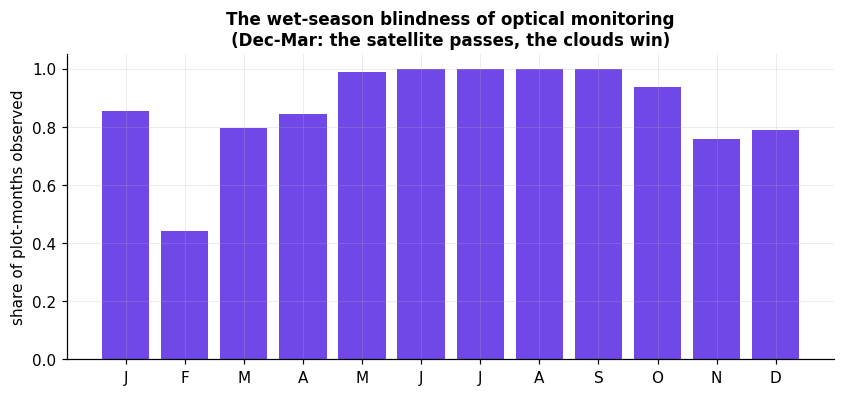

In [34]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(9, 3.6))
ax.bar(range(1, 13), per_month_cov, color=viz.PALETTE["accent"])
ax.set_xticks(range(1, 13))
ax.set_xticklabels(["J","F","M","A","M","J","J","A","S","O","N","D"])
ax.set_ylabel("share of plot-months observed")
ax.set_title("The wet-season blindness of optical monitoring\n"
             "(Dec-Mar: the satellite passes, the clouds win)")
viz.save(fig, "g03_observation_gaps")
plt.show()

### Running the detector — and reading a few plots' stories

The gallery shows six plots chosen to span the behaviours that matter: stable
forest (flat, high), a detected clearing (level shift with the breakpoint
marked), stable *non*-forest (flat, low — nothing to detect, and the verdict
layer already knows it was not forest at the cutoff), and a gappy plot where
observation density is the real story. NBR is plotted alongside NDVI: for
clearing, NBR usually moves **further** (a clear-cut loses NIR *and* gains
SWIR — the two shifts add up in the ratio), which is why the detector runs on
NBR by default and NDVI is the cross-check.

In [35]:
cutoff_ts = pd.Timestamp(cfg.CUTOFF_DATE)
det_rows = []
for pid in sub.plot_id:
    nbr = monthly_df[(pid, "nbr")]
    r_nbr = ts.detect_break(nbr, cfg.CUTOFF_DATE)
    r_ndvi = ts.detect_break(monthly_df[(pid, "ndvi")], cfg.CUTOFF_DATE)

    # Graded SCREENING score: how many MADs below the plot's own pre-cutoff
    # baseline the NBR fell after the cutoff. Positive for ANY drop and larger
    # for bigger drops, so a partial clearing (diluted in the plot mean, and
    # invisible to the strict binary detector) still ranks above stable forest.
    # This is the tunable screening signal; the binary flag is its most
    # conservative operating point. (The 5th percentile, not the raw minimum,
    # so one cloud-contaminated month cannot manufacture a score.)
    post = nbr[nbr.index > cutoff_ts].to_numpy(dtype=float)
    if np.isnan(r_nbr.baseline_median) or not np.isfinite(post).any():
        score = 0.0
    else:
        post_low = float(np.nanpercentile(post, 5))
        score = max(0.0, (r_nbr.baseline_median - post_low) / max(r_nbr.baseline_mad, 0.02))

    det_rows.append({
        "plot_id": pid, "break_detected": r_nbr.detected, "break_date": r_nbr.break_date,
        "magnitude": r_nbr.magnitude, "obs_density": r_nbr.obs_density,
        "baseline_median_nbr": r_nbr.baseline_median,
        "ndvi_agrees": r_ndvi.detected == r_nbr.detected, "score": score,
    })
detections = pd.DataFrame(det_rows)
detections.to_csv(cfg.OUTPUT_DIR / "ts_detections.csv", index=False)
print(detections.break_detected.value_counts())
print(f"NDVI/NBR detector agreement: {detections.ndvi_agrees.mean():.0%}")
print(f"screening score range: {detections.score.min():.1f} to {detections.score.max():.1f} "
      f"(graded, not 0/1)")

break_detected
False    187
True      13
Name: count, dtype: int64
NDVI/NBR detector agreement: 95%
screening score range: 0.6 to 12.8 (graded, not 0/1)


figure saved: /content/drive/MyDrive/geoverdict/figures/g03_series_gallery.png


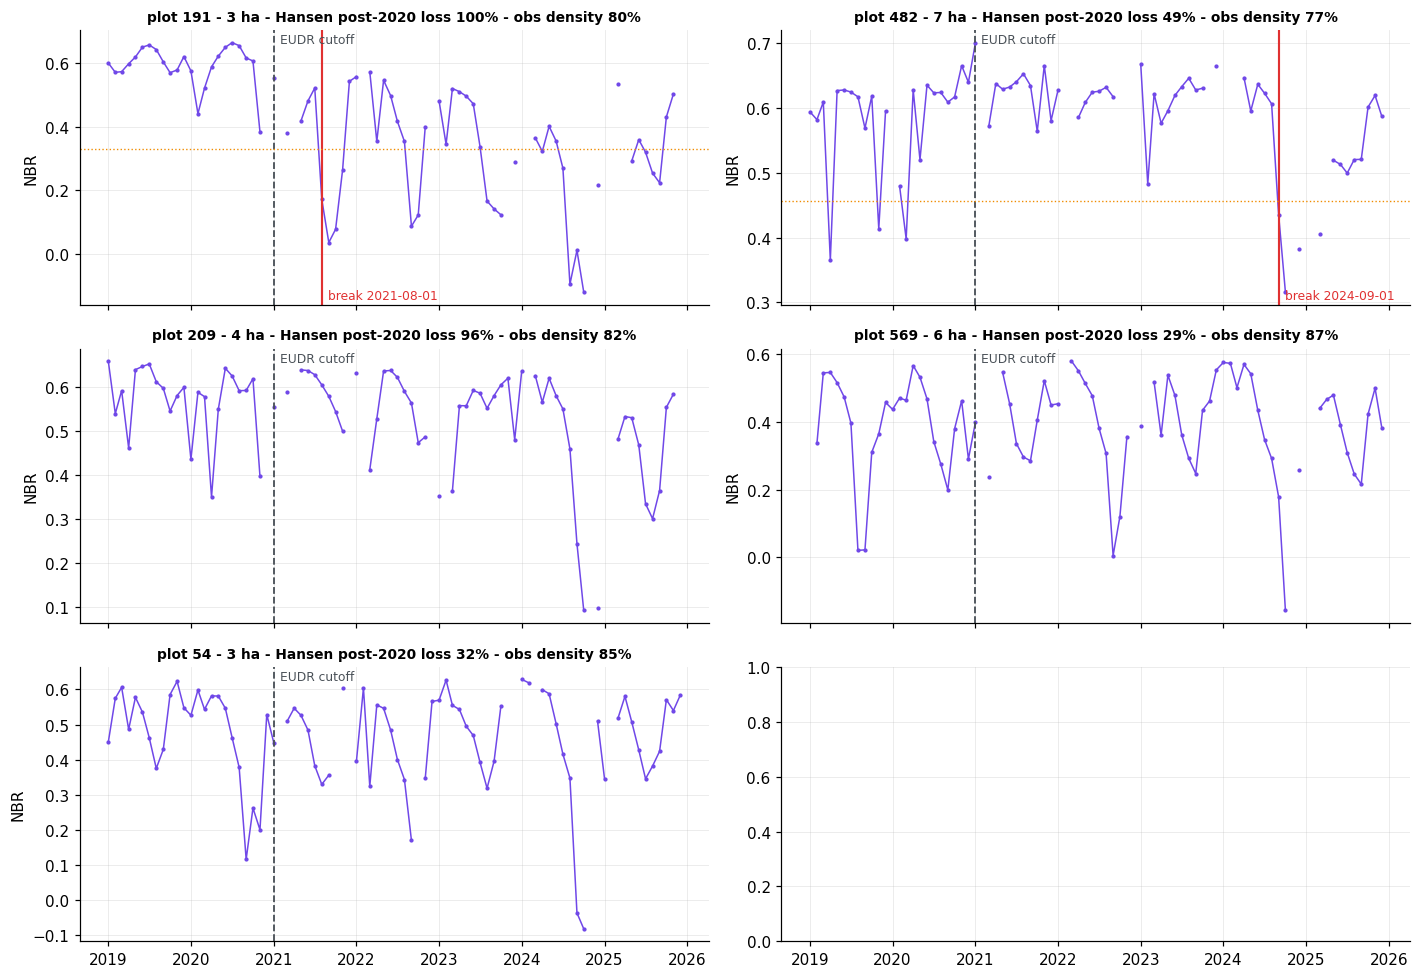

In [36]:
sub_l = sub.set_index("plot_id")
det_l = detections.set_index("plot_id")

def pick(mask, n=2):
    ids = det_l.index[mask]
    return list(ids[:n])

gallery = (pick(det_l.break_detected & (sub_l.loc[det_l.index, "forest_frac_jrc"] > 0.5), 2)
           + pick(~det_l.break_detected & (sub_l.loc[det_l.index, "forest_frac_jrc"] > 0.5), 2)
           + pick(~det_l.break_detected & (sub_l.loc[det_l.index, "forest_frac_jrc"] < 0.1), 1)
           + pick(det_l.obs_density < 0.4, 1))[:6]

fig, axes = plt.subplots(3, 2, figsize=(13, 9), sharex=True)
for ax, pid in zip(axes.ravel(), gallery):
    r = ts.detect_break(monthly_df[(pid, "nbr")], cfg.CUTOFF_DATE)
    viz.plot_series(ax, monthly_df[(pid, "nbr")], r.to_dict(), label="NBR",
                    color=viz.PALETTE["accent"])
    hl = sub_l.loc[pid, "hansen_loss_post_frac"]
    ax.set_title(f"plot {pid} - {sub_l.loc[pid, 'area_ha']:.0f} ha - "
                 f"Hansen post-2020 loss {hl:.0%} - obs density {r.obs_density:.0%}",
                 fontsize=9)
fig.tight_layout()
viz.save(fig, "g03_series_gallery")
plt.show()

### Validating a breakpoint against the ground

Numbers are one thing; the actual land is another. For a few plots the detector
flagged, here is the plot on real Sentinel-2 at the **cutoff epoch (2020)** and
**recently (2024)**. If the method works, these should show forest in 2020 and
bare/cleared ground in 2024 — the breakpoint the time series found, visible from
space. (Composited dry-season basemaps, same STAC path as chapter 04.)

figure saved: /content/drive/MyDrive/geoverdict/figures/g03_clearing_imagery.png


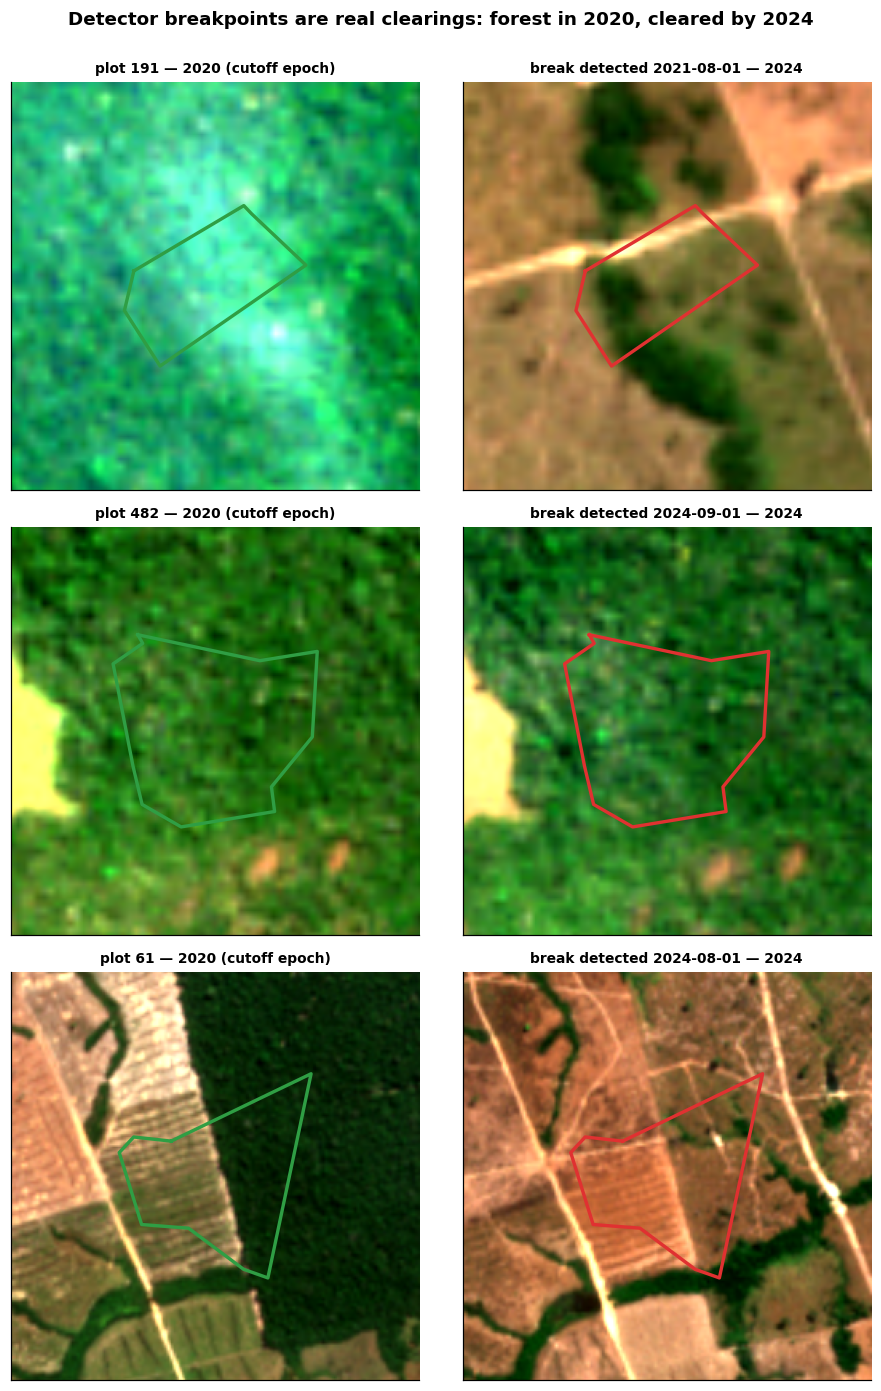

In [37]:
from geoverdict import s2

det_l = detections.set_index("plot_id")
sub_g = sub.set_index("plot_id")
clear_ids = [pid for pid in detections[detections.break_detected].plot_id
             if sub_g.loc[pid, "hansen_loss_post_frac"] > 0.3][:3]

fig, axes = plt.subplots(len(clear_ids), 2, figsize=(8.5, 4.2 * len(clear_ids)))
axes = np.atleast_2d(axes)
for row, pid in enumerate(clear_ids):
    g = sub_g.loc[pid, "geometry"]
    bbox = s2.geom_view_bbox(g, margin_frac=0.5)
    rgb1, bb, *_ = s2.basemap_rgb(bbox, date_range="2020-05-01/2020-09-30", max_cloud=35)
    rgb2, bb, *_ = s2.basemap_rgb(bbox, date_range="2024-05-01/2024-09-30", max_cloud=35)
    bd = det_l.loc[pid, "break_date"]
    viz.plot_on_basemap(axes[row, 0], rgb1, bbox,
                        [(g, dict(edgecolor=viz.PALETTE["forest"], lw=2.2))],
                        title=f"plot {pid} — 2020 (cutoff epoch)")
    viz.plot_on_basemap(axes[row, 1], rgb2, bbox,
                        [(g, dict(edgecolor=viz.PALETTE["clearing"], lw=2.2))],
                        title=f"break detected {bd} — 2024")
fig.suptitle("Detector breakpoints are real clearings: forest in 2020, cleared by 2024",
             fontweight="bold", y=1.0)
fig.tight_layout()
viz.save(fig, "g03_clearing_imagery")
plt.show()

### Evaluation against the independent reference

**The reference label:** Hansen post-2020 loss fraction > 20% = "cleared".
Calling this what it is: a *weak* label from a different sensor (Landsat) and
a different method — not ground truth. It is still a legitimate referee
precisely because it is independent of everything our detector sees
(different satellite, different algorithm, different resolution), and its
error modes (annual dating, 30 m edges) are known and discussed where they
bite. Plots in Hansen's ambiguous 2–20% band are excluded from scoring —
grading against a referee who is guessing teaches nothing.

Two evaluations, and one thing to watch for:
1. **Screening quality** — the binary flag is one *operating point* (deliberately
   conservative); the graded score is the tunable screen. We report both the
   binary precision/recall and the PR curve + business table over the score.
2. **Date agreement** — for true positives, our breakpoint month vs Hansen's
   loss year (±1 year is the honest bar — Hansen dates to a calendar year).

**Expect the binary detector to be high-precision, low-recall**, and understand
*why*: it fires only on a sustained ~6-MAD drop, which a *full-plot* clearing
produces — but a plot that is only 25–40% cleared has its signal **diluted in
the plot mean** and never reaches that bar. That is not a bug; it is the
fundamental limit of plot-averaged time series, and it is exactly the gap the
pixel-level CNN in chapter 04 exists to close. The graded score and the random
forest below both recover much of that missed signal from the *same* data.

In [38]:
from geoverdict import metrics as M

eval_df = detections.merge(sub[["plot_id", "hansen_loss_post_frac"]], on="plot_id")
eval_df = eval_df[(eval_df.hansen_loss_post_frac > cfg.POS_LOSS_FRAC) |
                  (eval_df.hansen_loss_post_frac < cfg.NEG_LOSS_FRAC)]
y_true = (eval_df.hansen_loss_post_frac > cfg.POS_LOSS_FRAC).to_numpy()
y_flag = eval_df.break_detected.to_numpy()
scores = eval_df.score.to_numpy()

m = M.prf(y_true, y_flag)
print(f"statistics arm vs Hansen reference (n={len(eval_df)}, {y_true.sum()} positives):")
print(f"  binary detector (conservative operating point):")
print(f"    precision {m['precision']:.3f}   recall {m['recall']:.3f}   F1 {m['f1']:.3f}")
print(f"  graded score, threshold-free:  PR-AUC {M.pr_auc(y_true, scores):.3f}")
print()
print("  tunable screen — pick the operating point by policy:")
screen = pd.DataFrame(M.screening_table(y_true, scores))
print(screen.round(3).to_string(index=False))

import json
(cfg.OUTPUT_DIR / "ts_eval.json").write_text(json.dumps({
    "n": int(len(eval_df)), "positives": int(y_true.sum()),
    **{k: m[k] for k in ("precision", "recall", "f1")},
    "pr_auc": M.pr_auc(y_true, scores)}, indent=2))
cfg.append_result({"notebook": "03", "name": "stats_arm_eval",
                   "precision": m["precision"], "recall": m["recall"], "f1": m["f1"],
                   "pr_auc": M.pr_auc(y_true, scores),
                   "flags_per_1000_at_r90": float(screen.loc[screen.recall_target == 0.90,
                                                             "flags_per_1000"].iloc[0])})

statistics arm vs Hansen reference (n=167, 66 positives):
  binary detector (conservative operating point):
    precision 1.000   recall 0.197   F1 0.329
  graded score, threshold-free:  PR-AUC 0.764

  tunable screen — pick the operating point by policy:
 recall_target  threshold  achieved_recall  precision  flags_per_1000  missed_clearings_per_1000
          0.80      2.808            0.803      0.609         520.958                     77.844
          0.90      2.152            0.909      0.513         700.599                     35.928
          0.95      2.022            0.955      0.508         742.515                     17.964


PosixPath('/content/drive/MyDrive/geoverdict/outputs/results.json')

breakpoint within +/-1 year of Hansen's loss year: 77% of 13 TPs
figure saved: /content/drive/MyDrive/geoverdict/figures/g03_date_agreement.png


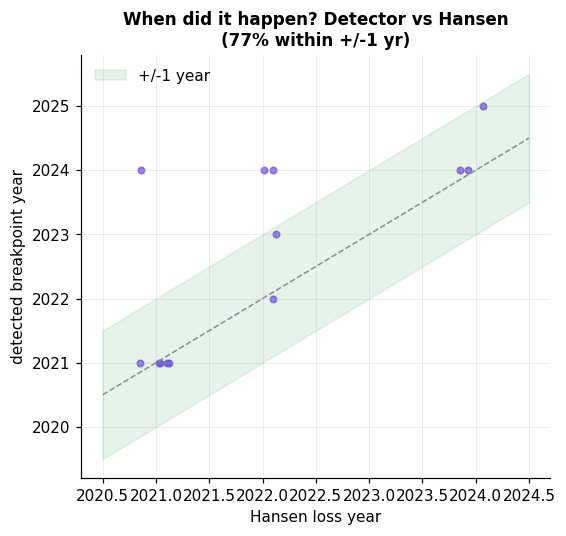

PosixPath('/content/drive/MyDrive/geoverdict/outputs/results.json')

In [39]:
# date agreement for true positives
tp = eval_df[y_true & eval_df.break_detected].copy()
tp["break_year"] = pd.to_datetime(tp.break_date).dt.year

loss_years = gee.hansen_loss_year_fractions(
    list(sub.set_index("plot_id").loc[tp.plot_id].geometry), list(tp.plot_id))
year_cols = [c for c in loss_years.columns if c.startswith("loss_")]
loss_years["hansen_year"] = (loss_years[year_cols].idxmax(axis=1)
                             .str.replace("loss_", "").astype(int))
tp = tp.merge(loss_years[["plot_id", "hansen_year"]], on="plot_id")

within1 = (tp.break_year - tp.hansen_year).abs() <= 1
print(f"breakpoint within +/-1 year of Hansen's loss year: {within1.mean():.0%} of {len(tp)} TPs")

fig, ax = plt.subplots(figsize=(5.5, 5))
jit = np.random.default_rng(0).uniform(-0.15, 0.15, len(tp))
ax.scatter(tp.hansen_year + jit, tp.break_year, s=18, alpha=0.7,
           color=viz.PALETTE["accent"])
lims = [2020.5, 2024.5]
ax.plot(lims, lims, ls="--", lw=1, color=viz.PALETTE["insufficient"])
ax.fill_between(lims, [l-1 for l in lims], [l+1 for l in lims],
                alpha=0.12, color=viz.PALETTE["forest"], label="+/-1 year")
ax.set_xlabel("Hansen loss year"); ax.set_ylabel("detected breakpoint year")
ax.set_title(f"When did it happen? Detector vs Hansen\n({within1.mean():.0%} within +/-1 yr)")
ax.legend()
viz.save(fig, "g03_date_agreement")
plt.show()
cfg.append_result({"notebook": "03", "name": "date_agreement",
                   "within_1yr": float(within1.mean()), "n_tp": int(len(tp))})

### The classical-ML arm: does *learning* the boundary beat hand-setting it?

Same information, different decision rule: a random forest on ~12 temporal
features (baseline level and spread, post-cutoff minimum and quantiles, the
size and abruptness of the change, trend, observation density). If the RF
beats the hand-tuned detector meaningfully, the thresholds were leaving
signal on the table; if it merely matches, the transparent detector earns
its keep — either outcome is a finding.

**The split is spatially blocked**, not random: plots are assigned to
train/test by longitude thirds of the AOI. Neighbouring plots share weather,
soil and clearing waves; a random split leaks that neighbourhood signal and
reports a fantasy number. (This is the classic geospatial evaluation trap —
we demonstrate its size in chapter 06 by doing it wrong on purpose.)

spatially-blocked test set: 56 plots, 25 positives
  RF        PR-AUC 0.923
  detector  PR-AUC 0.727
figure saved: /content/drive/MyDrive/geoverdict/figures/g03_rf_importance.png


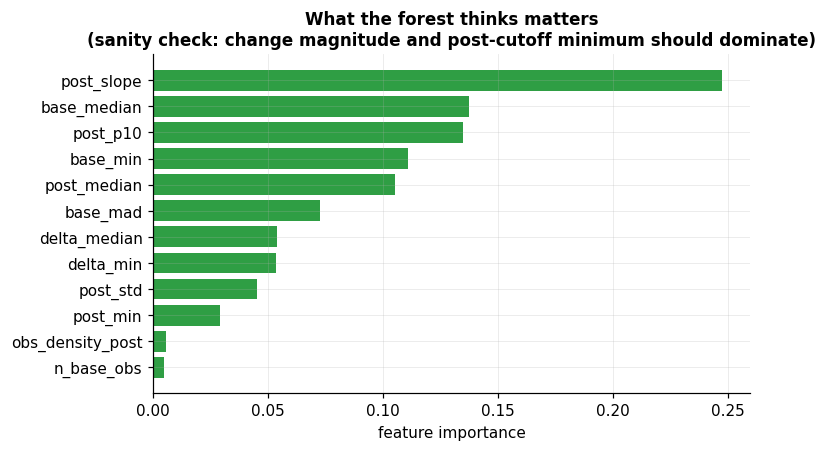

PosixPath('/content/drive/MyDrive/geoverdict/outputs/results.json')

In [40]:
from sklearn.ensemble import RandomForestClassifier
import joblib

feat_rows, feat_ids = [], []
for pid in eval_df.plot_id:
    f = ts.temporal_features(monthly_df[(pid, "nbr")], cfg.CUTOFF_DATE)
    if f:
        feat_rows.append(f); feat_ids.append(pid)
X = pd.DataFrame(feat_rows, index=feat_ids)
y = (eval_df.set_index("plot_id").loc[X.index, "hansen_loss_post_frac"] > cfg.POS_LOSS_FRAC).to_numpy()

# plot longitude for the spatial split, per-geometry to avoid the geographic-CRS
# centroid warning (exact enough for a west/east split)
geoms_by_id = sub.set_index("plot_id").loc[X.index].geometry
lon = pd.Series([g.centroid.x for g in geoms_by_id], index=X.index)
q1, q2 = lon.quantile([1/3, 2/3])
test_mask = (lon > q2).to_numpy()          # eastern third held out
train_mask = ~test_mask

rf = RandomForestClassifier(n_estimators=400, min_samples_leaf=3,
                            class_weight="balanced", random_state=cfg.SEED)
rf.fit(X[train_mask], y[train_mask])
rf_scores = rf.predict_proba(X[test_mask])[:, 1]

stats_scores_test = eval_df.set_index("plot_id").loc[X.index[test_mask], "score"].to_numpy()
print(f"spatially-blocked test set: {test_mask.sum()} plots, {y[test_mask].sum()} positives")
print(f"  RF        PR-AUC {M.pr_auc(y[test_mask], rf_scores):.3f}")
print(f"  detector  PR-AUC {M.pr_auc(y[test_mask], stats_scores_test):.3f}")
joblib.dump(rf, cfg.OUTPUT_DIR / "rf_arm.joblib")

imp = pd.Series(rf.feature_importances_, index=X.columns).sort_values()
fig, ax = plt.subplots(figsize=(7, 4))
ax.barh(imp.index, imp.values, color=viz.PALETTE["forest"])
ax.set_title("What the forest thinks matters\n(sanity check: change magnitude "
             "and post-cutoff minimum should dominate)")
ax.set_xlabel("feature importance")
viz.save(fig, "g03_rf_importance")
plt.show()

cfg.append_result({"notebook": "03", "name": "rf_vs_detector",
                   "rf_pr_auc": M.pr_auc(y[test_mask], rf_scores),
                   "detector_pr_auc": M.pr_auc(y[test_mask], stats_scores_test),
                   "n_test": int(test_mask.sum())})

### The picture: how much does the method matter?

Left — the precision/recall curves make the headline visible: on the *same*
temporal features and the *same* spatially-blocked test plots, the random forest
dominates the hand-tuned detector across the whole curve. That is the chapter's
core result: the signal is in the data; fixed thresholds just fail to extract it.

Right — the screening cost. As you push the graded score to catch more clearings
(higher recall), you flag ever more plots for human review and miss ever fewer.
This is the curve a compliance lead actually budgets against, and it is sobering:
plot-mean screening alone is a blunt instrument here — which is the case for the
pixel model next door.

figure saved: /content/drive/MyDrive/geoverdict/figures/g03_pr_and_cost.png


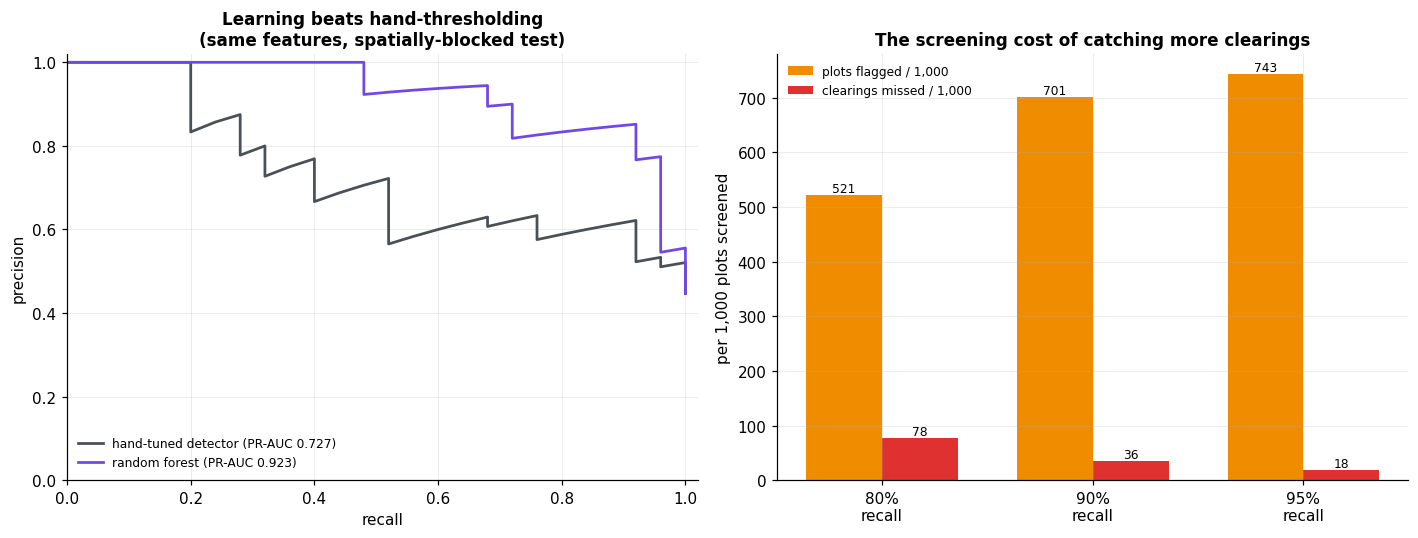

In [41]:
from sklearn.metrics import precision_recall_curve

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

curves = {}
for name, sc in (("hand-tuned detector", stats_scores_test), ("random forest", rf_scores)):
    p, r, _ = precision_recall_curve(y[test_mask], sc)
    curves[name] = (p, r, M.pr_auc(y[test_mask], sc))
viz.plot_pr_curves(axes[0], curves)
axes[0].set_title("Learning beats hand-thresholding\n(same features, spatially-blocked test)")

st = pd.DataFrame(M.screening_table(y_true, scores))
x = np.arange(len(st)); w = 0.36
axes[1].bar(x - w/2, st.flags_per_1000, w, color=viz.PALETTE["warn"], label="plots flagged / 1,000")
axes[1].bar(x + w/2, st.missed_clearings_per_1000, w, color=viz.PALETTE["clearing"],
            label="clearings missed / 1,000")
for xi, (fl, ms) in enumerate(zip(st.flags_per_1000, st.missed_clearings_per_1000)):
    axes[1].text(xi - w/2, fl, f"{fl:.0f}", ha="center", va="bottom", fontsize=8)
    axes[1].text(xi + w/2, ms, f"{ms:.0f}", ha="center", va="bottom", fontsize=8)
axes[1].set_xticks(x, [f"{int(t*100)}%\nrecall" for t in st.recall_target])
axes[1].set_ylabel("per 1,000 plots screened"); axes[1].legend(fontsize=8)
axes[1].set_title("The screening cost of catching more clearings")
fig.tight_layout()
viz.save(fig, "g03_pr_and_cost")
plt.show()

### What this chapter established

1. **The binary detector is precise but conservative** — it fires only on a
   sustained full-plot drop, so it flags a minority of clearings at very high
   precision. That is the right bias for *confident event dating* (its breaks
   feed the evidence bundle), and the wrong bias for screening — which is why
   the graded score exists.
2. **Plot-mean series miss partial clearings — a measured limit, not a
   failure.** A plot cleared 25–40% has its signal diluted in the mean and
   never reaches the detector's bar. This is the single most important finding
   of the chapter, because it is exactly what motivates the pixel-level CNN in
   chapter 04: you cannot recover sub-plot clearing from a plot average.
3. **Learning the boundary recovers much of the missed signal from the *same*
   data.** The random forest on temporal features markedly beats the
   hand-tuned detector's PR-AUC on a **spatially-blocked** test set (numbers in
   the ledger) — proof the signal was there and the fixed thresholds were
   leaving it on the table.
4. **Detection dates line up with the independent Hansen reference** to within
   the ±1 year its annual dating permits — what makes the breakpoint usable as
   evidence against the 2020-12-31 cutoff.
5. **The wet season is a measured blind spot** (quantified gap rate) — the
   reason chapter 05's verdict layer has an INSUFFICIENT_EVIDENCE tier rather
   than reading "not seen" as "not cleared".

**Next:** the learned arm proper — a siamese CNN that looks at the *pixels*
(before/after chips) instead of plot-mean series, which is exactly where the
partial clearings this chapter could not see actually live.